In [1]:
from torch.nn import Linear
from torch_geometric.nn import GCNConv, GINConv
import torch.nn.functional as F
import torch
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

torch.manual_seed(42)

/Users/simon/rep/studium/graph_learning/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Task: Expressivity and the Lottery Ticket Hypothesis

To shed light on the intricate interplay between expressivity and the LTH for GNNs, proceed as follows:

**(a)** Explore the expressivity of **untrained randomly initialized GNNs** and the effect when pruning is applied to them (i.e., the initial weights are sparsified by setting elements to zero).

* **(i)** Devise a method $M(\Phi, D)$ to empirically determine the expressivity of a given GNN $\Phi$ on a given dataset $D$ for both nodes and graphs.

For this purpose we will choose the **Empirical Distinguishability Score**

To quantify the expressivity of an untrained, pruned GNN $\Phi$ on a dataset $D$, we measure its ability to assign unique embedding vectors to structurally distinct inputs. This method is grounded in the Weisfeiler-Lehman (1-WL) isomorphism test.

### 1. Preliminaries
* Let $D = \{x_1, x_2, \dots, x_N\}$ be the set of inputs (where $x_i$ can be a node or a graph).
* Let $\Phi(x; \theta, m)$ be the GNN with random initialization $\theta$ and a binary pruning mask $m$.
* Let $h_i = \Phi(x_i)$ be the output embedding for input $x_i$.

### 2. Pairwise Distinguishability
We define the **Distinguishability Indicator** $\delta(i, j)$ for a pair of inputs. The GNN successfully distinguishes the pair if their embeddings are separated by more than a numerical tolerance $\epsilon$ (e.g., $\epsilon = 10^{-5}$).

$$
\delta(i, j) = \mathbb{1}(||h_i - h_j||_2 > \epsilon)
$$

### 3. Empirical Distinguishability Score
The Empirical Distinguishability Score (EDS) is computed as the ratio of distinguishable pairs to the total number of pairs:

$$
E(\Phi, D) = \frac{\sum_{i < j, c_i \neq c_j} \delta(i, j)}{\sum_{i < j} \mathbb{1}(c_i \neq c_j)}
$$

#### Interpretation
* **$E = 1.0$**: The pruned GNN $\Phi$ is **Fully Expressive**. It retains enough capacity to separate all inputs that a dense 1-WL equivalent network could separate.
* **$E < 1.0$**: The GNN suffers from **Embedding Collapse**. The pruning has removed critical pathways, causing distinct graph structures to map to identical representations.

In [14]:
class GNN(torch.nn.Module):
    def __init__(self, input_dim=1433,output_dim=7, hidden_channels=16, num_layers=2, dropout=0.5,inner_layers=GCNConv,output_layer=Linear):
        super(GNN, self).__init__()
        self.convs = torch.nn.ModuleList()
        self.convs.append(inner_layers(input_dim, hidden_channels))
        for _ in range(num_layers - 2):
            self.convs.append(inner_layers(hidden_channels, hidden_channels))
        self.convs.append(inner_layers(hidden_channels, hidden_channels))
        self.dropout = dropout
        self.output_layer = output_layer(hidden_channels, output_dim)

    def forward(self, x, edge_index):
        for conv in self.convs[:-1]:
            x = conv(x, edge_index)
            x = torch.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.convs[-1](x, edge_index)
        x = self.output_layer(x)

        return x

class GIN(GNN):
    def __init__(self, input_dim=1433,output_dim=7, hidden_channels=16, num_layers=2, dropout=0.5):
        super(GIN, self).__init__(input_dim,output_dim, hidden_channels, num_layers, dropout,inner_layers=lambda in_c,out_c: GINConv(Linear(in_c,out_c)),output_layer=Linear)




def EMD(phi:GNN,D,eps=10e-5):
    delta = lambda x,y: np.linalg.norm(x-y) > eps
    phi.eval()
    with torch.no_grad():
        embeddings = [phi(data.x, data.edge_index) for data in D]
    ind = np.triu_indices(len(D),k=1)
    dist_pairs = 0
    for i,j in zip(ind[0],ind[1]):
        dist_pairs += delta(embeddings[i].cpu().numpy().mean(axis=0),embeddings[j].cpu().numpy().mean(axis=0)).astype(int)
    return dist_pairs / (len(D)*(len(D)-1)/2)
        

**(ii)** Use a 3-layer **Graph Isomorphism Network (GIN)** and a **Graph Convolutional Network (GCN)** for $\Phi$ with a random initialization and activation functions of your choice.

Write code to randomly prune a given fraction
$$
\rho \in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99]
$$
of weight elements.

If you use Python and PyTorch Geometric, you can, for example, access and prune the models’ weights as follows:

```python
for name, param in model.named_parameters():
    # Variable name usually contains
    # type and position of a layer.
    if 'conv' in name:
        # Only prune the trainable weights.
        if 'weight' in name and param.requires_grad:
            # Generate a random pruning mask
            pruning_mask = ...
            # Apply via elementwise product *
            # and write back to the param storage.
            param.data.copy_(pruning_mask * param.data)

In [3]:
def prune_GNN(phi:GNN, p=0.5):
    for name, param in phi.named_parameters():
        if 'weight' in name:
            mask = torch.rand_like(param) > p
            param.data.mul_(mask)
    return phi

**(iii)** After completing the previous steps, evaluate $M$ for both models and all values of $\rho$ given above and the datasets **MUTAG**, **PTC FM**, and **ENZYMES**. Always use the whole dataset without splitting.

Filter out copies of isomorphic graphs, i.e., only keep one instance of each isomorphism type, and rerun the experiments.

In [4]:
from torch_geometric.datasets import TUDataset

mutag = TUDataset(root='data/TUDataset', name='MUTAG',cleaned=True)
ptc_fm = TUDataset(root='data/TUDataset', name='PTC_FM',cleaned=True)
enzymes = TUDataset(root='data/TUDataset', name='ENZYMES',cleaned=True)

In [5]:
mutag_dim = mutag.num_node_features
ptc_fm_dim = ptc_fm.num_node_features
enzymes_dim = enzymes.num_node_features
print(f'MUTAG node feature dimension: {mutag_dim}')
print(f'PTC_FM node feature dimension: {ptc_fm_dim}')
print(f'ENZYMES node feature dimension: {enzymes_dim}') 

MUTAG node feature dimension: 7
PTC_FM node feature dimension: 17
ENZYMES node feature dimension: 3


In [21]:
from tqdm import tqdm

datasets = [mutag,ptc_fm,enzymes]
input_dims = [mutag_dim,ptc_fm_dim,enzymes_dim]
output_dim = hidden_dim = 16
emd_eps = 0.1

scores = pd.DataFrame(columns=['Dataset','Model','Pruning_Level','EMD_Score'])
with torch.no_grad():
    for in_dim,ds in tqdm(list(zip(input_dims, datasets)), desc="Datasets"):
        for p in tqdm(np.linspace(0, 0.9, 10), desc="Pruning p", leave=False):
            gcn = GNN(input_dim=in_dim,output_dim=output_dim,hidden_channels=hidden_dim,num_layers=3,dropout=0.0,inner_layers=GCNConv,output_layer=Linear)
            gcn = prune_GNN(gcn,p=p)
            emd_score_gcn = EMD(gcn,ds,eps=emd_eps)

            gin = GIN(input_dim=in_dim,output_dim=output_dim,hidden_channels=hidden_dim,num_layers=3,dropout=0.0)
            gin = prune_GNN(gin,p=p)
            emd_score_gin = EMD(gin,ds,eps=emd_eps)

            scores = pd.concat([scores,pd.DataFrame({'Dataset':[ds.name]*2,
                                                     'Model':['GCN','GIN'],
                                                     'Pruning_Level':[p]*2,
                                                     'EMD_Score':[emd_score_gcn,emd_score_gin]})],ignore_index=True)


Datasets:   0%|          | 0/3 [00:00<?, ?it/s]/var/folders/sb/srd6vlp11bbg593vb9r4m72r0000gp/T/ipykernel_32318/3244593731.py:20: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  scores = pd.concat([scores,pd.DataFrame({'Dataset':[ds.name]*2,
Datasets: 100%|██████████| 3/3 [00:31<00:00, 10.58s/it]


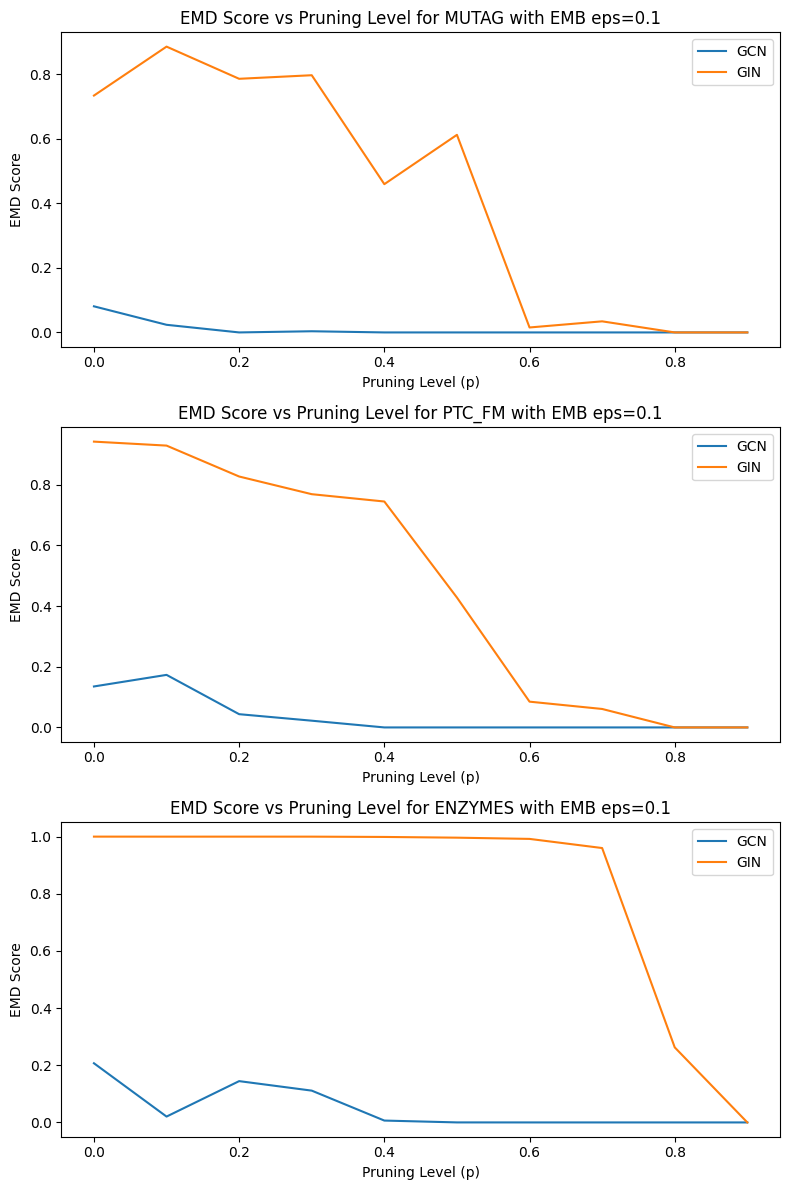

In [24]:
fig, ax = plt.subplots(3,1, figsize=(8,12))
for i, ds_name in enumerate(scores['Dataset'].unique()):
    for model_name in scores['Model'].unique():
        subset = scores[(scores['Dataset'] == ds_name) & (scores['Model'] == model_name)]
        ax[i].plot(subset['Pruning_Level'], subset['EMD_Score'], label=model_name)
    ax[i].set_title(f'EMD Score vs Pruning Level for {ds_name} with EMB eps={emd_eps}')
    ax[i].set_xlabel('Pruning Level (p)')
    ax[i].set_ylabel('EMD Score')
    ax[i].legend()
plt.tight_layout()
plt.show()